In [1]:
import yaml # type: ignore
import torch # type: ignore
import pickle
import numpy as np # type: ignore
from PIL import Image # type: ignore
from dotmap import DotMap # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Use matplotlib's tex rendering
import matplotlib # type: ignore
matplotlib.rcParams['text.usetex'] = True

from pud.visualizers.visualize import plot_agent_paths
from pud.utils import set_global_seed, set_env_seed
from pud.algos.vision.vision_agent import LagVisionUVFDDPG
from pud.collectors.constrained_collector import ConstrainedCollector
from pud.envs.habitat_navigation_env import GoalConditionedHabitatPointWrapper
from pud.envs.safe_habitatenv.safe_habitat_wrappers import safe_habitat_env_load_fn
from pud.envs.safe_habitatenv.safe_habitat_wrappers import SafeGoalConditionedHabitatPointWrapper, SafeGoalConditionedHabitatPointQueueWrapper
from pud.algos.policies import VisualSearchPolicy, VisualConstrainedSearchPolicy, VisualMultiAgentSearchPolicy, VisualConstrainedMultiAgentSearchPolicy

/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Load the evaluation configuration

In [2]:
env = "SC3_Staging_11"  # Change the environment here, follow the paper for acceptable environments

config_file="models/" + env + "/config.yaml"
illustration_pb_file="pud/plots/data/illustration_pbs.pkl"
illustration_png_file="pud/plots/figures/paper/sc3_staging_11.png"
unconstrained_ckpt_file="models/" + env + "/unconstrained_ckpt.pth"
constrained_ckpt_file="models/" + env + "/constrained_ckpt.pth"

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)

# User defined parameters for evaluation
config.device = "cuda:0"
config.replay_buffer.max_size = 1000
config.agent_cost_kwargs.cost_limit = 1.5

set_global_seed(config.seed)

#### Load the evaluation environment

In [3]:
gym_env_wrappers = []
gym_env_wrapper_kwargs = []
for wrapper_name in config.wrappers:
    if wrapper_name == "GoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(GoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())
    elif wrapper_name == "SafeGoalConditionedHabitatPointQueueWrapper":
        gym_env_wrappers.append(SafeGoalConditionedHabitatPointQueueWrapper)
        gym_env_wrapper_kwargs.append(config.wrappers[wrapper_name].toDict())

eval_env = safe_habitat_env_load_fn(
    env_kwargs=config.env.toDict(),
    cost_f_args=config.cost_function.toDict(),
    cost_limit=config.agent_cost_kwargs.cost_limit,
    max_episode_steps=config.time_limit.max_episode_steps,
    gym_env_wrappers=gym_env_wrappers,  # type: ignore
    wrapper_kwargs=gym_env_wrapper_kwargs,
    terminate_on_timeout=True,
    )
set_env_seed(eval_env, config.seed + 2)

[17:36:30:448849]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_00` Value : `navmeshes/Baked_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[17:36:30:448873]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_01` Value : `navmeshes/Baked_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[17:36:30:448879]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `Baked_sc4_staging_02` Value : `navmeshes/Baked_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `external_data/replica_cad/replica_cad_baked_lighting`
[17:36:30:448885]:[Error]:[Metadata] SceneDatasetAttributesManager.cpp(305)::validateMap : `navmesh_instances` Key : `

Renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 550.120
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
[INFO] Calling the APSP construction function


100%|██████████| 206/206 [00:00<00:00, 16161.21it/s]

APSP construction time in (s):  0.020587921142578125
[INFO] Skipping the reset in HabitatNavigationEnv.__init__ because setup is not ready yet
[INFO] SafeHabitatNavigationEnv Setup: 0.007688999176025391 s



/scratch/miniconda3/envs/safe_visual_mapf/lib/python3.9/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


#### Load the inference agent

In [4]:
config.agent["action_dim"] = eval_env.action_space.shape[0]  # type: ignore
config.agent["max_action"] = float(eval_env.action_space.high[0])  # type: ignore

agent = LagVisionUVFDDPG(
    width=config.env.simulator_settings.width,
    height=config.env.simulator_settings.height,
    in_channels=4,
    act_fn=torch.nn.SELU,
    encoder="VisualEncoder",
    device=config.device,
    **config.agent.toDict(),
    cost_kwargs=config.agent_cost_kwargs.toDict(),
)

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()

LagVisionUVFDDPG(
  (actor): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l1): Linear(in_features=512, out_features=256, bias=True)
    (l2): Linear(in_features=256, out_features=256, bias=True)
    (l3): Linear(in_features=256, out_features=2, bias=True)
  )
  (actor_target): VisualGoalConditionedActor(
    (encoder): VisualEncoder(
      (conv_net): Sequential(
        (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
        (1): SELU()
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(4, 4))
        (3): SELU()
        (4): Flatten(start_dim=1, end_dim=-1)
      )
      (l1): Linear(in_features=128, out_features=256, bias=True)
    )
    (l

#### Sample a replay buffer to form our search graph

In [5]:
rb_vec_grid, rb_vec_visual = ConstrainedCollector.sample_initial_unconstrained_states(eval_env, config.replay_buffer.max_size, habitat=True)

agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))
unconstrained_pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore
unconstrained_pcost = agent.get_pairwise_cost(rb_vec_visual, aggregate=None)  # type: ignore

agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
constrained_pdist = agent.get_pairwise_dist(rb_vec_visual, aggregate=None)  # type: ignore

if len(constrained_ckpt_file) > 0:
    agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
else:
    agent.load_state_dict(torch.load(unconstrained_ckpt_file, map_location=config.device))

#### Sample (start, goal) problems for the agent

In [6]:
illustration_problems = pickle.load(open(illustration_pb_file, "rb"))
single_agent_problem = [illustration_problems[0]]
multi_agent_problems = [illustration_problems[0], illustration_problems[5], illustration_problems[6], illustration_problems[7]]
eval_env.set_use_q(True) # type: ignore
eval_env.set_prob_constraint(1.0) # type: ignore

In [7]:
def add_inset_axes(fig, ax, ax_index, eval_env, start, goal, obs, wps=None, agent_id=0, start_point=0.11, side_factor=0.2, xlim=(10, 20), ylim=(9, 18)):
    height, width = eval_env.get_map_height(), eval_env.get_map_width()
    axs_inset = fig.add_axes([start_point + ax_index * side_factor, -0.15, 0.20, 0.4])
    im = np.asarray(Image.open(illustration_png_file)) # type: ignore
    axs_inset.imshow(im, extent=[0, height+2, 0, width-2])
    axs_inset.set_xticks([])
    axs_inset.set_yticks([])
    axs_inset.set_xlim(*xlim)
    axs_inset.set_ylim(*ylim)
    axs_inset = plot_agent_paths(agent_id, start, goal, obs, "", axs_inset, wps=wps, use_agent_id=False)
    return axs_inset

## Single-Agent Comparisons

### Unconstrained Low-Level Policy

In [8]:
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=single_agent_problem.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectory(agent, eval_env, habitat=True)

[WARN]: queue from goal conditioned env is empty


### Unconstrained Low-Level Policy with Graph Search

In [9]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=single_agent_problem.copy())  # type: ignore

search_policy = VisualSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), pdist=unconstrained_pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectory(search_policy, eval_env, habitat=True, input_start=start, input_goal=goal)

/scratch/Work/Multi_Agent_Research/Hierarchical_Constrained_SORB/clean_code/cc-sorb-rev/pud/algos/vision/vision_agent.py:360: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  observation=torch.FloatTensor(state["observation"]),


[WARN]: queue from goal conditioned env is empty


### Constrained Low-Level Policy

In [10]:
agent.load_state_dict(torch.load(constrained_ckpt_file, map_location=config.device))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=single_agent_problem.copy())  # type: ignore
start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectory(agent, eval_env, habitat=True)

[WARN]: queue from goal conditioned env is empty


### Constrained Low-Level Policy with Graph Search

In [11]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=single_agent_problem.copy())  # type: ignore

ckpts = {"unconstrained": unconstrained_ckpt_file, "constrained": constrained_ckpt_file}
constrained_search_policy = VisualConstrainedSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), pdist=constrained_pdist, pcost=unconstrained_pcost, ckpts=ckpts, open_loop=True, no_waypoint_hopping=True, max_search_steps=3, max_cost_limit=config.agent_cost_kwargs.cost_limit)
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectory(constrained_search_policy, eval_env, habitat=True)

[WARN]: queue from goal conditioned env is empty


#### Plot the single-agent comparison

In [12]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

start_image = start[1]
goal_image = goal[1]
start = start[0] / normalization_factor
goal = goal[0] / normalization_factor

unconstrained_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_observations])
unconstrained_search_observations = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations])
unconstrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints])

constrained_observations = np.array([obs[0] / normalization_factor for obs in constrained_observations])

constrained_search_image_observations = np.array([obs[1] for obs in constrained_search_observations])
constrained_search_image_waypoints = np.array([wp[1].cpu() for wp in constrained_search_waypoints])
constrained_search_observations = np.array([obs[0] / normalization_factor for obs in constrained_search_observations])
constrained_search_waypoints = np.array([wp[0] / normalization_factor for wp in constrained_search_waypoints])

(<matplotlib.patches.Rectangle at 0x7c68315f8d90>,
 (<matplotlib.patches.ConnectionPatch at 0x7c68315b09a0>,
  <matplotlib.patches.ConnectionPatch at 0x7c68315bd1c0>))

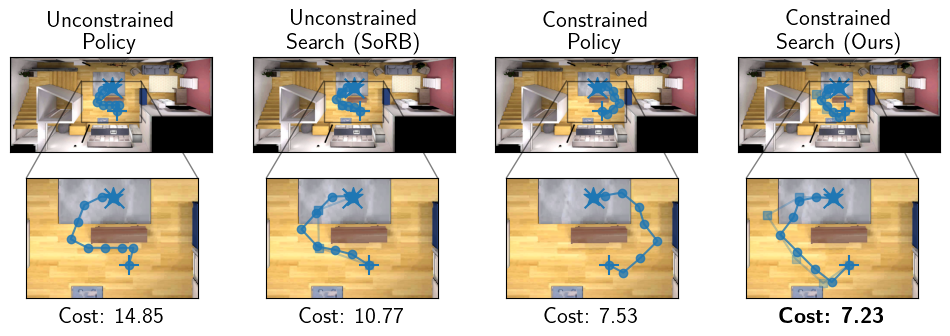

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

for ax in axs:
    im = np.asarray(Image.open(illustration_png_file))
    ax.imshow(im, extent=[0, height+2, 0, width-2])
    ax.set_xticks([])
    ax.set_yticks([])

xlim, ylim = (12, 22), (5, 12)

axs[0] = plot_agent_paths(0, start, goal, unconstrained_observations, "Unconstrained\nPolicy", axs[0], use_agent_id=False)
axs_0_inset = add_inset_axes(fig, axs[0], 0, eval_env, start, goal, unconstrained_observations, xlim=xlim, ylim=ylim)
axs[0].text(0.5, -0.15, f"Cost: {unconstrained_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_0_inset.transAxes, weight='bold', fontsize=16)
axs[0].indicate_inset_zoom(axs_0_inset, edgecolor="black")

axs[1] = plot_agent_paths(0, start, goal, unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[1], wps=unconstrained_search_waypoints, use_agent_id=False)
axs_1_inset = add_inset_axes(fig, axs[1], 1, eval_env, start, goal, unconstrained_search_observations, wps=unconstrained_search_waypoints, xlim=xlim, ylim=ylim)
axs[1].text(0.5, -0.15, f"Cost: {unconstrained_search_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_1_inset.transAxes, weight='bold', fontsize=16)
axs[1].indicate_inset_zoom(axs_1_inset, edgecolor="black")

axs[2] = plot_agent_paths(0, start, goal, constrained_observations, "Constrained\nPolicy", axs[2], use_agent_id=False)
axs_2_inset = add_inset_axes(fig, axs[2], 2, eval_env, start, goal, constrained_observations, xlim=xlim, ylim=ylim)
axs[2].text(0.5, -0.15, f"Cost: {constrained_records['cumulative_costs']:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_2_inset.transAxes, weight='bold', fontsize=16)
axs[2].indicate_inset_zoom(axs_2_inset, edgecolor="black")

axs[3] = plot_agent_paths(0, start, goal, constrained_search_observations, "Constrained\nSearch (Ours)", axs[3], wps=constrained_search_waypoints, use_agent_id=False)
axs_3_inset = add_inset_axes(fig, axs[3], 3, eval_env, start, goal, constrained_search_observations, wps=constrained_search_waypoints, xlim=xlim, ylim=ylim)
axs[3].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_records['cumulative_costs']:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs_3_inset.transAxes, weight='bold', fontsize=16)
axs[3].indicate_inset_zoom(axs_3_inset, edgecolor="black")

# plt.legend(loc="lower center", bbox_to_anchor=(-1.6, -0.5), ncol=4, fontsize=12)
# _ = plt.suptitle("Single-Agent Trajectory Comparison", fontsize=24)
# plt.savefig("pud/plots/figures/paper/single_agent_habitatenv_comparison.svg", bbox_inches="tight")

## Multi-Agent Comparisons

### Unconstrained Low-Level Policy

In [14]:
n_agents = 4
agent.load_state_dict(torch.load(unconstrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=multi_agent_problems.copy())  # type: ignore
start, goal, unconstrained_observations, _, _, unconstrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents, habitat=True)

### Unconstrained Low-Level Policy with Graph Search

In [15]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=multi_agent_problems.copy())  # type: ignore

ma_search_policy = VisualMultiAgentSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), n_agents, pdist=unconstrained_pdist, open_loop=True, max_search_steps=3, no_waypoint_hopping=True)
start, goal, unconstrained_search_observations, unconstrained_search_waypoints, _, unconstrained_search_records = ConstrainedCollector.get_trajectories(ma_search_policy, eval_env, n_agents, habitat=True, input_starts=start, input_goals=goal)

### Constrained Low-Level Policy

In [16]:
agent.load_state_dict(torch.load(constrained_ckpt_file))
agent.to(torch.device(config.device))
agent.eval()

eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=multi_agent_problems.copy())  # type: ignore
start, goal, constrained_observations, _, _, constrained_records = ConstrainedCollector.get_trajectories(agent, eval_env, n_agents, habitat=True)

### Constrained Low-Level Policy with Graph Search

In [17]:
eval_env.duration = 300  # type: ignore
eval_env.set_pbs(pb_list=multi_agent_problems.copy())  # type: ignore

constrained_ma_search_policy = VisualConstrainedMultiAgentSearchPolicy(agent, (rb_vec_grid, rb_vec_visual), n_agents, pdist=constrained_pdist, pcost=unconstrained_pcost, open_loop=True, no_waypoint_hopping=True, max_search_steps=3, max_cost_limit=config.agent_cost_kwargs.cost_limit, ckpts={"unconstrained": unconstrained_ckpt_file, "constrained": constrained_ckpt_file})
start, goal, constrained_search_observations, constrained_search_waypoints, _, constrained_search_records = ConstrainedCollector.get_trajectories(constrained_ma_search_policy, eval_env, n_agents, habitat=True)

#### Plot the multi-agent comparison

In [18]:
height, width = 1.0, 1.0
normalization_factor = np.array([height, width])

for agent_id in range(n_agents):
    start[agent_id] = start[agent_id][0] / normalization_factor
    goal[agent_id] = goal[agent_id][0] / normalization_factor

    unconstrained_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in unconstrained_observations[agent_id]]) # type: ignore
    unconstrained_search_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in unconstrained_search_observations[agent_id]]) # type: ignore
    unconstrained_search_waypoints[agent_id] = np.array([wp[0] / normalization_factor for wp in unconstrained_search_waypoints[agent_id]]) # type: ignore

    constrained_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in constrained_observations[agent_id]])
    constrained_search_observations[agent_id] = np.array([obs[0] / normalization_factor for obs in constrained_search_observations[agent_id]])
    constrained_search_waypoints[agent_id] = np.array([wp[0] / normalization_factor for wp in constrained_search_waypoints[agent_id]])

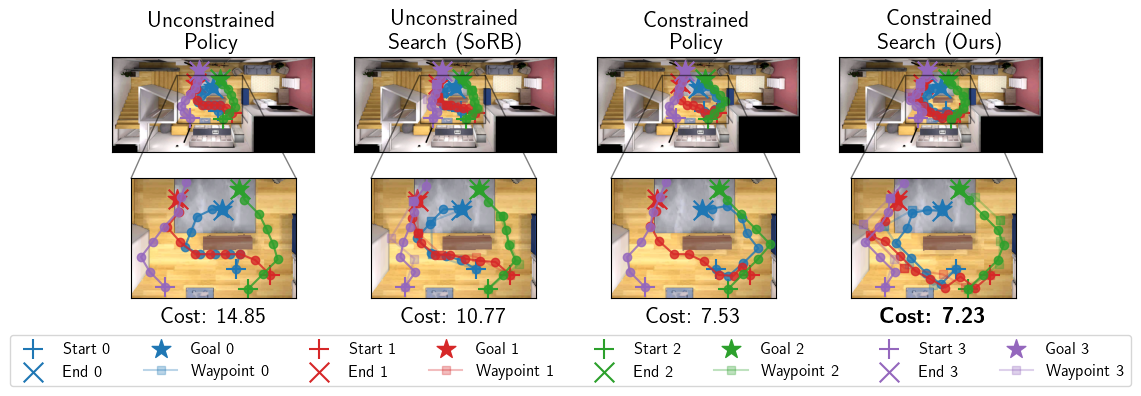

In [19]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
height, width = eval_env.get_map_height(), eval_env.get_map_width()

for ax in axs:
    im = np.asarray(Image.open(illustration_png_file))
    ax.imshow(im, extent=[0, height+2, 0, width-2])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

unconstrained_cc = max([record["cumulative_costs"] for record in unconstrained_records])
constrained_cc = max([record["cumulative_costs"] for record in constrained_records])
unconstrained_search_cc = max([record["cumulative_costs"] for record in unconstrained_search_records])
constrained_search_cc = max([record["cumulative_costs"] for record in constrained_search_records])
for agent_id in range(n_agents):
    agent_unconstrained_observations = np.array(unconstrained_observations[agent_id])
    agent_unconstrained_search_observations = np.array(unconstrained_search_observations[agent_id])
    agent_constrained_observations = np.array(constrained_observations[agent_id])
    agent_constrained_search_observations = np.array(constrained_search_observations[agent_id])
    
    agent_unconstrained_search_waypoints = np.array(unconstrained_search_waypoints[agent_id])
    agent_constrained_search_waypoints = np.array(constrained_search_waypoints[agent_id])

    axs[0] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_observations, "Unconstrained\nPolicy", axs[0]) 
    axs[1] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_unconstrained_search_observations, "Unconstrained\nSearch (SoRB)", axs[1], wps=agent_unconstrained_search_waypoints)
    axs[2] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_observations, "Constrained\nPolicy", axs[2])
    axs[3] = plot_agent_paths(agent_id, start[agent_id], goal[agent_id], agent_constrained_search_observations, "Constrained\nSearch (Ours)", axs[3], wps=agent_constrained_search_waypoints)

inset_agent_id = 0
xlim, ylim = (11, 22), (5, 13)
axs_0_inset = add_inset_axes(fig, axs[0], 0, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(unconstrained_observations[inset_agent_id]), agent_id=inset_agent_id, xlim=xlim, ylim=ylim)
for n_agent in range(1, n_agents):
    axs_0_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(unconstrained_observations[n_agent]), "", axs_0_inset, wps=None, use_agent_id=False)
axs[0].text(0.5, -0.15, f"Cost: {unconstrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_0_inset.transAxes, weight='bold', fontsize=16)
axs[0].indicate_inset_zoom(axs_0_inset, edgecolor="black")

axs_1_inset = add_inset_axes(fig, axs[1], 1, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(unconstrained_search_observations[inset_agent_id]), agent_id=inset_agent_id, wps=np.array(unconstrained_search_waypoints[inset_agent_id]), xlim=xlim, ylim=ylim)
for n_agent in range(1, n_agents):
    axs_1_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(unconstrained_search_observations[n_agent]), "", axs_1_inset, wps=np.array(unconstrained_search_waypoints[n_agent]), use_agent_id=False)
axs[1].text(0.5, -0.15, f"Cost: {unconstrained_search_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_1_inset.transAxes, weight='bold', fontsize=16)
axs[1].indicate_inset_zoom(axs_1_inset, edgecolor="black")

axs_2_inset = add_inset_axes(fig, axs[2], 2, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(constrained_observations[inset_agent_id]), agent_id=inset_agent_id, xlim=xlim, ylim=ylim)
for n_agent in range(1, n_agents):
    axs_2_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(constrained_observations[n_agent]), "", axs_2_inset, wps=None, use_agent_id=False)
axs[2].text(0.5, -0.15, f"Cost: {constrained_cc:.2f}", horizontalalignment="center", verticalalignment="center", transform=axs_2_inset.transAxes, weight='bold', fontsize=16)
axs[2].indicate_inset_zoom(axs_2_inset, edgecolor="black")

axs_3_inset = add_inset_axes(fig, axs[3], 3, eval_env, start[inset_agent_id], goal[inset_agent_id], np.array(constrained_search_observations[inset_agent_id]), wps=np.array(constrained_search_waypoints[inset_agent_id]), agent_id=inset_agent_id, xlim=xlim, ylim=ylim)
for n_agent in range(1, n_agents):
    axs_3_inset = plot_agent_paths(n_agent, start[n_agent], goal[n_agent], np.array(constrained_search_observations[n_agent]), "", axs_3_inset, wps=np.array(constrained_search_waypoints[n_agent]), use_agent_id=False)
axs[3].text(0.5, -0.15, rf"\textbf{{Cost: {constrained_search_cc:.2f}}}", horizontalalignment="center", verticalalignment="center", transform=axs_3_inset.transAxes, weight='bold', fontsize=16)
axs[3].indicate_inset_zoom(axs_3_inset, edgecolor="black")

handles, labels = axs[1].get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(-1.7, -0.8), ncol=8, fontsize=12)
# _ = plt.suptitle("Multi-Agent Trajectory Comparison", fontsize=24)
plt.savefig("pud/plots/figures/paper/multi_agent_habitatenv_comparison.svg", bbox_inches="tight")